# 第5章 単層ネットワーク: 分類 (Single-layer Networks: Classification)
## 5.1 識別関数 (Discriminant Functions)

### 本節の目的と概要
本ノートブックでは、Christopher M. Bishop & Hugh Bishop による『*Deep Learning: Foundations and Concepts*』(2024年刊) の **Chapter 5: Single-layer Networks: Classification** の冒頭部分である **Section 5.1: Discriminant Functions** を体系的かつ厳密に解説・実装・検証します。

分類（Classification）の目的は、入力ベクトル $\mathbf{x} \in \mathbb{R}^D$ を $K$ 個の離散クラス $\mathcal{C}_k$ ($k=1, \dots, K$) のいずれか1つに割り当てることです。クラスは互いに素（disjoint）であると仮定され、入力空間は決定境界（decision surface）によって複数の決定領域（decision regions）へと分割されます。

機械学習における分類手法は大きく3つのアプローチに分類されます：
1. **識別関数 (Discriminant Functions)**: 入力 $\mathbf{x}$ を直接クラスラベルに写像する決定規則を構築する（本節の主テーマ）。
2. **生成的確率モデル (Generative Probabilistic Models)**: クラス条件付き密度 $p(\mathbf{x}|\mathcal{C}_k)$ と事前確率 $p(\mathcal{C}_k)$ をモデル化し、ベイズの定理を用いて事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を計算して決定を下す（Section 5.3）。
   $$p(\mathcal{C}_k|\mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_k)p(\mathcal{C}_k)}{p(\mathbf{x})} \tag{5.1}$$
3. **識別的確率モデル (Discriminative Probabilistic Models)**: 事後クラス確率 $p(\mathcal{C}_k|\mathbf{x})$ を直接パラメトリックモデル（ロジスティック回帰など）でモデル化して最適化する（Section 5.4）。

本ノートブックでは、最も直接的で幾何学的解釈に富む線形識別関数（Linear Discriminant Functions）を対象に、以下の構成で徹底的に深掘りします：

- **5.1.1 2クラスの識別関数 (Two classes)**: 線形超平面、法線ベクトル $\mathbf{w}$ の直交性、原点からの変位 $-\frac{w_0}{\|\mathbf{w}\|}$、直交射影 $\mathbf{x}_\perp$、マージン $r = \frac{y(\mathbf{x})}{\|\mathbf{w}\|}$ の厳密導出 (**Figure 5.1**)。
- **5.1.2 多クラスの識別関数 (Multiple classes)**: 1対他 (1-vs-rest) および 1対1 (1-vs-1) のヒューリスティックによる曖昧領域の発生機構 (**Figure 5.2**)、および統一的な $K$ クラス線形識別関数における決定領域の凸性（Convexity）証明 (**Figure 5.3**)。
- **5.1.3 1-of-K 符号化 (1-of-K coding)**: ターゲットベクトルの表現形式と事後確率ベクトルとしての条件付き期待値解釈。
- **5.1.4 分類のための最小二乗法 (Least squares for classification)**: 正規方程式による厳密解、ターゲット和の制約保存性（$\sum_k y_k(\mathbf{x}) = 1$ の不変性）、および外れ値に対する脆弱性（ロジスティック回帰との比較、**Figure 5.4**）。

In [1]:
import os
import sys
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from IPython.display import Image, display

# プロジェクトルートの設定
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style
from common.discriminant_functions import (
    LinearDiscriminant2Class,
    LinearDiscriminantMultiClass,
    OneVersusRestClassifier,
    OneVersusOneClassifier,
    to_one_of_k,
    LeastSquaresClassifier,
    LogisticRegression2Class,
    plot_figure_5_1_geometry,
    plot_figure_5_2_ambiguities,
    plot_figure_5_3_convex_regions,
    plot_figure_5_4_least_squares_outliers,
    generate_all_section_5_1_figures,
)

# スタイルの初期化
setup_style()
print("Environment and modules successfully imported.")

Environment and modules successfully imported.


---
### 5.1.1 Two classes

2クラス問題における最も基本的な線形識別関数は、入力ベクトル $\mathbf{x}$ の線形結合として次のように定義されます：

$$y(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + w_0 \tag{5.2}$$

ここで $\mathbf{w}$ は重みベクトル（weight vector）、$w_0$ はバイアスパラメータ（bias parameter）です。
決定規則は以下の通りです：
- $y(\mathbf{x}) > 0$ のとき、クラス $\mathcal{C}_1$ に割り当てる（領域 $\mathcal{R}_1$）。
- $y(\mathbf{x}) \le 0$ のとき、クラス $\mathcal{C}_2$ に割り当てる（領域 $\mathcal{R}_2$）。

対応する決定境界（decision surface）は $y(\mathbf{x}) = 0$ で定義され、$D$ 次元入力空間における $(D-1)$ 次元の超平面（hyperplane）を形成します。

#### 1. 法線ベクトル $\mathbf{w}$ の直交性
決定境界上の任意の2点 $\mathbf{x}_A, \mathbf{x}_B$ を考えます。定義より $y(\mathbf{x}_A) = y(\mathbf{x}_B) = 0$ ですから、
$$y(\mathbf{x}_A) - y(\mathbf{x}_B) = (\mathbf{w}^T \mathbf{x}_A + w_0) - (\mathbf{w}^T \mathbf{x}_B + w_0) = \mathbf{w}^T (\mathbf{x}_A - \mathbf{x}_B) = 0$$
差ベクトル $(\mathbf{x}_A - \mathbf{x}_B)$ は超平面（決定境界）に含まれる任意の平行ベクトルを表すため、**重みベクトル $\mathbf{w}$ は決定境界上のすべてのベクトルに直交**します。すなわち、$\mathbf{w}$ は超平面の向き（法線方向）を決定します。

#### 2. 原点から決定超平面までの最短距離
原点 $\mathbf{0}$ から超平面 $y(\mathbf{x})=0$ への最短距離は、超平面上の点 $\mathbf{x}$ を単位法線ベクトル $\frac{\mathbf{w}}{\|\mathbf{w}\|}$ 上に射影した長さの絶対値です：
$$\frac{\mathbf{w}^T \mathbf{x}}{\|\mathbf{w}\|} = -\frac{w_0}{\|\mathbf{w}\|} \tag{5.3}$$
したがって、**バイアス $w_0$ は決定境界の原点からの位置（変位）を制御**します。

#### 3. 任意点 $\mathbf{x}$ の直交射影と符号付きマージン $r$
任意の点 $\mathbf{x}$ を決定境界上の直交射影 $\mathbf{x}_\perp$ と法線方向の変位 $r \frac{\mathbf{w}}{\|\mathbf{w}\|}$ に直交分解します：
$$\mathbf{x} = \mathbf{x}_\perp + r \frac{\mathbf{w}}{\|\mathbf{w}\|} \tag{5.4}$$
この両辺に左から $\mathbf{w}^T$ を掛け、$w_0$ を加えます：
$$\mathbf{w}^T \mathbf{x} + w_0 = \mathbf{w}^T \mathbf{x}_\perp + w_0 + r \frac{\mathbf{w}^T \mathbf{w}}{\|\mathbf{w}\|}$$
ここで $y(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + w_0$ であり、また $\mathbf{x}_\perp$ は決定境界面上にあるため $y(\mathbf{x}_\perp) = \mathbf{w}^T \mathbf{x}_\perp + w_0 = 0$ です。さらに $\frac{\mathbf{w}^T \mathbf{w}}{\|\mathbf{w}\|} = \|\mathbf{w}\|$ であるため、
$$y(\mathbf{x}) = 0 + r \|\mathbf{w}\| \implies r = \frac{y(\mathbf{x})}{\|\mathbf{w}\|} \tag{5.5}$$
が得られます。すなわち、$y(\mathbf{x})$ の値は、点 $\mathbf{x}$ から決定境界までの**符号付き直交距離（signed perpendicular distance）に比例**しています。

#### 4. 拡張入力表現 (Augmented Input Notation)
ダミー入力 $x_0 = 1$ を導入し、拡張重みベクトル $\widetilde{\mathbf{w}} = (w_0, \mathbf{w}^T)^T$ と拡張入力ベクトル $\widetilde{\mathbf{x}} = (1, \mathbf{x}^T)^T$ を定義すると、識別関数は簡潔な内積として表されます：
$$y(\mathbf{x}) = \widetilde{\mathbf{w}}^T \widetilde{\mathbf{x}} \tag{5.6}$$
この表現では、決定面は $(D+1)$ 次元の拡張空間において原点を通る $D$ 次元の超平面となります。

--- LinearDiscriminant2Class 数学的不変量の検証 ---
Weight vector: [3. 4.], norm: 5.0000
Bias w0: -12.0
Distance from origin (-w0 / ||w||): 2.4000
pA on boundary: y(pA) = 0.000000
pB on boundary: y(pB) = 0.000000
Orthogonality check w^T (pA - pB) = 0.000000
Point p = [5. 5.]:
  y(p) = 23.0000
  Signed margin r = y(p) / ||w|| = 4.6000
  Projected point p_perp = [2.24 1.32]
  y(p_perp) = 1.776357e-15 (厳密に0)
  Distance ||p - p_perp|| = 4.6000 (マージン |r| と完全一致)
Figure saved successfully to: result/fig_5_1_discriminant_geometry.png


Figure saved successfully to: 5/result/fig_5_1_discriminant_geometry.png


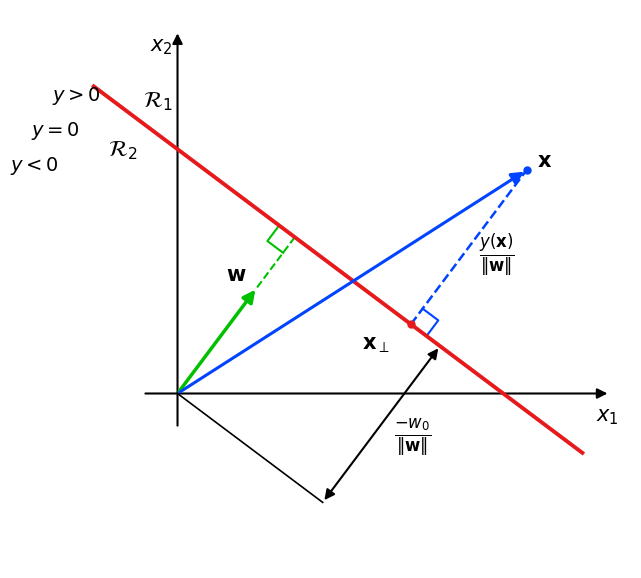

In [2]:
# 5.1.1 実装検証: 2クラス線形識別関数の幾何学的特性の数値的検証
w_test = np.array([3.0, 4.0])  # ||w|| = 5.0
w0_test = -12.0
disc2 = LinearDiscriminant2Class(w=w_test, w0=w0_test)

print("--- LinearDiscriminant2Class 数学的不変量の検証 ---")
print(f"Weight vector: {disc2.w}, norm: {disc2.w_norm:.4f}")
print(f"Bias w0: {disc2.w0}")
print(f"Distance from origin (-w0 / ||w||): {disc2.distance_from_origin():.4f}")

# 決定境界上の2点
pA = np.array([4.0, 0.0])
pB = np.array([0.0, 3.0])
print(f"pA on boundary: y(pA) = {disc2.decision_function(pA):.6f}")
print(f"pB on boundary: y(pB) = {disc2.decision_function(pB):.6f}")
print(f"Orthogonality check w^T (pA - pB) = {np.dot(disc2.w, pA - pB):.6f}")

# 任意点 p = [5, 5] の直交射影とマージン
p = np.array([5.0, 5.0])
r = disc2.margin(p)
p_perp = disc2.project(p)
print(f"Point p = {p}:")
print(f"  y(p) = {disc2.decision_function(p):.4f}")
print(f"  Signed margin r = y(p) / ||w|| = {r:.4f}")
print(f"  Projected point p_perp = {p_perp}")
print(f"  y(p_perp) = {disc2.decision_function(p_perp):.6e} (厳密に0)")
print(f"  Distance ||p - p_perp|| = {np.linalg.norm(p - p_perp):.4f} (マージン |r| と完全一致)")

# Figure 5.1 の生成・保存
fig_5_1 = plot_figure_5_1_geometry(filepath="result/fig_5_1_discriminant_geometry.png")
plt.show()

---
### 5.1.2 Multiple classes

$K > 2$ クラスの場合への線形識別関数の拡張を考えます。単純な発想として、2クラス分類器を複数組み合わせるヒューリスティック手法が考えられますが、これらは深刻な未分類・曖昧領域を生じさせます（Duda & Hart, 1973）。

#### 1. 1対他分類器 (One-versus-the-rest classifier) の欠陥
$K-1$ 個の2クラス分類器を用い、各分類器 $k$ で「クラス $\mathcal{C}_k$ に属するか、属さないか」を二値判定します。
- **欠陥**: 複数の分類器が同時に「所属する（$y > 0$）」と判定した場合、あるいはどの分類器も所属しないと判定した場合、入力空間に**どのクラスにも一意に割り当てられない曖昧領域（ambiguous regions）** が発生します（**Figure 5.2 左図**の緑色領域）。

#### 2. 1対1分類器 (One-versus-one classifier) の欠陥
すべてのクラスペア $(\mathcal{C}_k, \mathcal{C}_j)$ に対して $\frac{K(K-1)}{2}$ 個の二値分類器を用意し、多数決投票（majority vote）によって所属クラスを決定します。
- **欠陥**: 3すくみのような循環投票（$\mathcal{C}_1 > \mathcal{C}_2 > \mathcal{C}_3 > \mathcal{C}_1$）が生じる中央領域では投票数が同数となり、**過半数勝者が存在しない曖昧領域**が生じます（**Figure 5.2 右図**の緑色三角形）。

#### 3. 統一的 $K$ クラス線形識別関数
これらの曖昧性を排除するため、$K$ 個の線形関数を一括して定義します：

$$y_k(\mathbf{x}) = \mathbf{w}_k^T \mathbf{x} + w_{k0}, \quad k=1, \dots, K \tag{5.7}$$

そして、**出力値が最大となるクラスへ割り当てる決定規則**を採用します：
$$\mathbf{x} \in \mathcal{C}_k \iff y_k(\mathbf{x}) > y_j(\mathbf{x}) \quad (\forall j \neq k)$$

クラス $\mathcal{C}_k$ とクラス $\mathcal{C}_j$ の間の決定境界は $y_k(\mathbf{x}) = y_j(\mathbf{x})$ で与えられ、次式で定義される超平面となります：
$$(\mathbf{w}_k - \mathbf{w}_j)^T \mathbf{x} + (w_{k0} - w_{j0}) = 0 \tag{5.8}$$
これは 5.1.1 の2クラス識別関数と全く同型であり、法線ベクトルは $(\mathbf{w}_k - \mathbf{w}_j)$ となります。

#### 4. 決定領域の凸性（Convexity）定理
統一的 $K$ クラス線形識別関数の決定領域 $\mathcal{R}_k$ は**常に単連結（singly connected）かつ凸集合（convex set）** です。

**【証明】**
決定領域 $\mathcal{R}_k$ 内の任意の2点 $\mathbf{x}_A, \mathbf{x}_B$ をとります。この2点を結ぶ線分上の任意の点 $\widehat{\mathbf{x}}$ は、実数 $\lambda \in [0, 1]$ を用いて次のように表されます：
$$\widehat{\mathbf{x}} = \lambda \mathbf{x}_A + (1 - \lambda) \mathbf{x}_B \tag{5.9}$$
線形性より、クラス $k$ の識別関数値は次の通りです：
$$y_k(\widehat{\mathbf{x}}) = \mathbf{w}_k^T (\lambda \mathbf{x}_A + (1-\lambda)\mathbf{x}_B) + w_{k0} = \lambda (\mathbf{w}_k^T \mathbf{x}_A + w_{k0}) + (1-\lambda)(\mathbf{w}_k^T \mathbf{x}_B + w_{k0}) = \lambda y_k(\mathbf{x}_A) + (1-\lambda) y_k(\mathbf{x}_B) \tag{5.10}$$
仮定より $\mathbf{x}_A \in \mathcal{R}_k$ かつ $\mathbf{x}_B \in \mathcal{R}_k$ であるため、任意の $j \neq k$ に対し $y_k(\mathbf{x}_A) > y_j(\mathbf{x}_A)$ かつ $y_k(\mathbf{x}_B) > y_j(\mathbf{x}_B)$ が成立します。
$\lambda \ge 0$ および $(1-\lambda) \ge 0$ であり、かつ少なくとも一方は狭義正であることから、
$$y_k(\widehat{\mathbf{x}}) > \lambda y_j(\mathbf{x}_A) + (1-\lambda) y_j(\mathbf{x}_B) = y_j(\widehat{\mathbf{x}}) \quad (\forall j \neq k)$$
したがって、線分上の任意の点 $\widehat{\mathbf{x}}$ もまた領域 $\mathcal{R}_k$ に属します。よって $\mathcal{R}_k$ は凸集合です（**Q.E.D.**）

Figure saved successfully to: result/fig_5_2_multiclass_ambiguities.png
Figure saved successfully to: 5/result/fig_5_2_multiclass_ambiguities.png


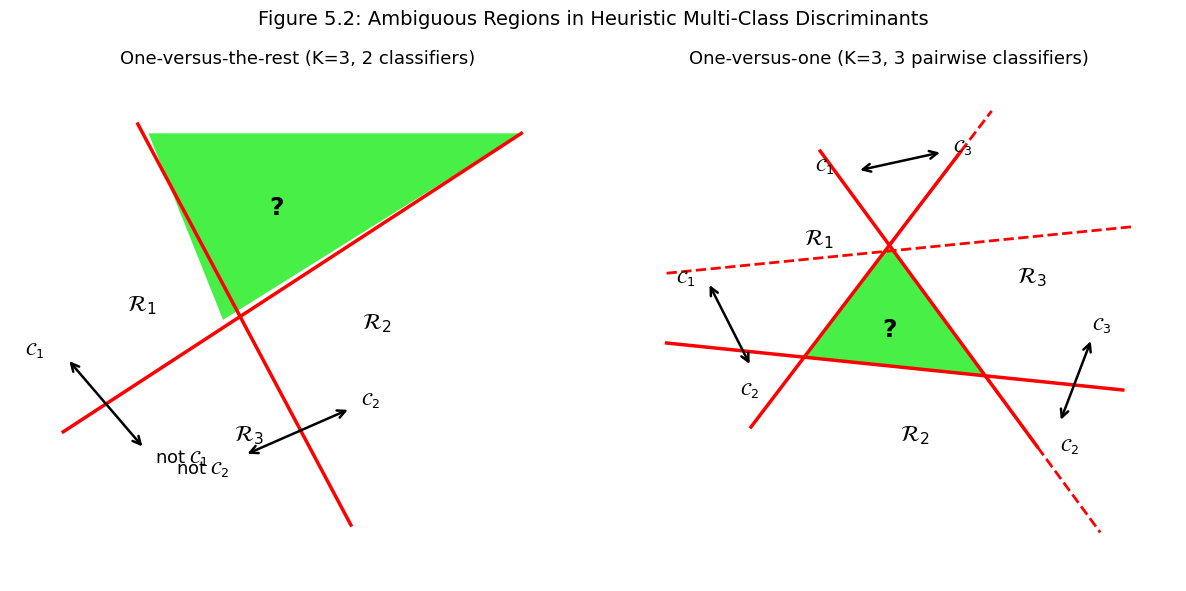

Figure saved successfully to: result/fig_5_3_convex_regions.png
Figure saved successfully to: 5/result/fig_5_3_convex_regions.png


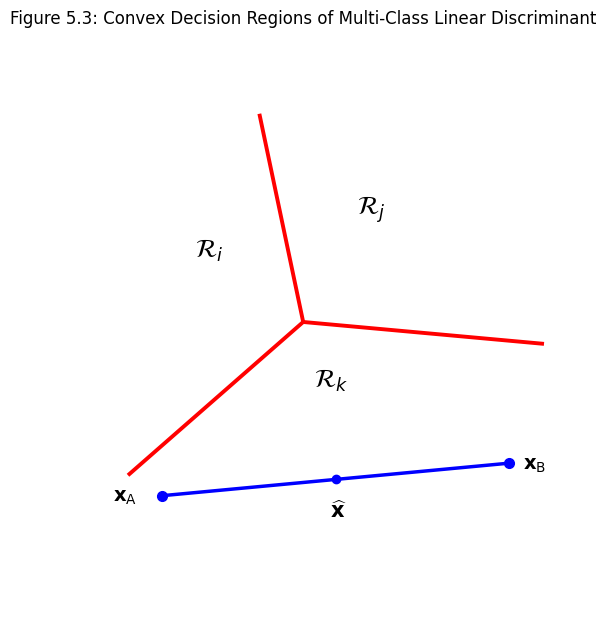


--- 凸性定理 (Eq 5.9 - 5.10) の検証 ---
xA = [2.31993942 0.98658484], class = 0
xB = [ 3.32442641 -2.87660889], class = 0
線分上の全100点がクラス0に属するか: True (定理通り凸性を満足)


In [3]:
# 5.1.2 実装検証: 多クラス識別関数の凸性検証 & Figure 5.2, 5.3 の生成
# 1. Figure 5.2: 1対他 / 1対1 ヒューリスティックにおける曖昧領域の可視化
fig_5_2 = plot_figure_5_2_ambiguities(filepath="result/fig_5_2_multiclass_ambiguities.png")
plt.show()

# 2. Figure 5.3: Kクラス線形識別関数における凸決定領域の可視化
fig_5_3 = plot_figure_5_3_convex_regions(filepath="result/fig_5_3_convex_regions.png")
plt.show()

# 3. 凸性定理の数値的検証 (モンテカルロ法による線分内サンプリング)
np.random.seed(42)
W_mc = np.array([
    [1.5, -1.0, -0.5],
    [0.2,  1.2, -1.4]
])
w0_mc = np.array([0.0, 0.5, -0.3])
mc_model = LinearDiscriminantMultiClass(W_mc, w0_mc)

# クラス0に属する2点を探索
points_in_0 = []
while len(points_in_0) < 2:
    candidate = np.random.uniform(-5, 5, 2)
    if mc_model.predict(candidate) == 0:
        points_in_0.append(candidate)

xA, xB = points_in_0
is_convex = mc_model.verify_convexity(xA, xB, num_points=100)
print(f"\n--- 凸性定理 (Eq 5.9 - 5.10) の検証 ---")
print(f"xA = {xA}, class = {mc_model.predict(xA)}")
print(f"xB = {xB}, class = {mc_model.predict(xB)}")
print(f"線分上の全100点がクラス0に属するか: {is_convex} (定理通り凸性を満足)")

---
### 5.1.3 1-of-K coding

分類問題におけるターゲット変数の表現方法を整理します。
- **2クラス分類**: 単一の二値変数 $t \in \{0, 1\}$ を用い、$t=1$ をクラス $\mathcal{C}_1$、$t=0$ をクラス $\mathcal{C}_2$ に対応させるのが一般的です。このとき $t$ は $\mathcal{C}_1$ である確率と解釈できます。
- **$K > 2$ クラス分類**: 長さ $K$ の二値ベクトル $\mathbf{t} \in \{0, 1\}^K$ を用いる **1-of-K 符号化（one-hot encoding）** を採用します。

対象データがクラス $\mathcal{C}_j$ に属する場合、ターゲットベクトル $\mathbf{t}$ は第 $j$ 成分 $t_j = 1$ のみを取り、それ以外のすべての成分は 0 となります。
例えば $K=5$ クラスにおいてクラス 2 に属するサンプルのターゲットベクトルは次式で与えられます：

$$\mathbf{t} = (0, 1, 0, 0, 0)^T \tag{5.11}$$

各要素 $t_k$ は「対象がクラス $\mathcal{C}_k$ である確率（極値 0 または 1 をとる）」と解釈でき、ターゲットベクトルの条件付き期待値は事後クラス確率ベクトルに一致します：
$$\mathbb{E}[\mathbf{t}|\mathbf{x}] = (p(\mathcal{C}_1|\mathbf{x}), \dots, p(\mathcal{C}_K|\mathbf{x}))^T$$

In [4]:
# 5.1.3 実装検証: 1-of-K 符号化
sample_labels = np.array([1, 0, 4, 2, 3])
T_one_hot = to_one_of_k(sample_labels, num_classes=5)

print("--- 1-of-K 符号化 (Eq 5.11) の検証 ---")
for lbl, vec in zip(sample_labels, T_one_hot):
    print(f"Class {lbl} -> Target vector t = {vec}, Sum = {vec.sum():.1f}")

assert np.all(T_one_hot.sum(axis=1) == 1.0), "1-of-K ベクトルの総和は常に 1.0 でなければなりません。"
print("全サンプルにおいて総和制約 sum_k t_k = 1.0 を確認しました。")

--- 1-of-K 符号化 (Eq 5.11) の検証 ---
Class 1 -> Target vector t = [0. 1. 0. 0. 0.], Sum = 1.0
Class 0 -> Target vector t = [1. 0. 0. 0. 0.], Sum = 1.0
Class 4 -> Target vector t = [0. 0. 0. 0. 1.], Sum = 1.0
Class 2 -> Target vector t = [0. 0. 1. 0. 0.], Sum = 1.0
Class 3 -> Target vector t = [0. 0. 0. 1. 0.], Sum = 1.0
全サンプルにおいて総和制約 sum_k t_k = 1.0 を確認しました。


---
### 5.1.4 Least squares for classification

第4章で学んだ通り、線形回帰において二乗和誤差関数の最小化はパラメータの厳密な閉形式解（closed-form solution）をもたらします。この最小二乗形式を分類問題に適用することを検討します。

#### 1. 行列形式のモデル定式化
各クラス $\mathcal{C}_k$ に対する線形モデルを次のように定義します：
$$y_k(\mathbf{x}) = \mathbf{w}_k^T \mathbf{x} + w_{k0} \tag{5.12}$$
これらをベクトル表記でまとめると、拡張入力 $\widetilde{\mathbf{x}} = (1, \mathbf{x}^T)^T$ とパラメータ行列 $\widetilde{\mathbf{W}} = [\widetilde{\mathbf{w}}_1, \dots, \widetilde{\mathbf{w}}_K]$ を用いて次のように表されます：
$$\mathbf{y}(\mathbf{x}) = \widetilde{\mathbf{W}}^T \widetilde{\mathbf{x}} \tag{5.13}$$
ここで $\widetilde{\mathbf{w}}_k = (w_{k0}, \mathbf{w}_k^T)^T$ です。

#### 2. 二乗和誤差関数の最小化と正規方程式の導出
訓練データセット $\{\mathbf{x}_n, \mathbf{t}_n\}_{n=1}^N$ に対し、第 $n$ 行が $\mathbf{t}_n^T$ であるターゲット行列 $\mathbf{T} \in \mathbb{R}^{N \times K}$、および第 $n$ 行が $\widetilde{\mathbf{x}}_n^T$ である計画行列 $\widetilde{\mathbf{X}} \in \mathbb{R}^{N \times (D+1)}$ を定義します。
二乗和誤差関数はトレースを用いて次のように書けます：

$$E_D(\widetilde{\mathbf{W}}) = \frac{1}{2} \mathrm{Tr} \left\{ (\widetilde{\mathbf{X}}\widetilde{\mathbf{W}} - \mathbf{T})^T (\widetilde{\mathbf{X}}\widetilde{\mathbf{W}} - \mathbf{T}) \right\} \tag{5.14}$$

これを $\widetilde{\mathbf{W}}$ に関して微分してゼロとおきます：
$$\nabla_{\widetilde{\mathbf{W}}} E_D(\widetilde{\mathbf{W}}) = \widetilde{\mathbf{X}}^T (\widetilde{\mathbf{X}}\widetilde{\mathbf{W}} - \mathbf{T}) = \mathbf{0}$$
整理すると、最小二乗解の閉形式が得られます：

$$\widetilde{\mathbf{W}} = (\widetilde{\mathbf{X}}^T \widetilde{\mathbf{X}})^{-1} \widetilde{\mathbf{X}}^T \mathbf{T} = \widetilde{\mathbf{X}}^\dagger \mathbf{T} \tag{5.15}$$

ここで $\widetilde{\mathbf{X}}^\dagger$ は計画行列 $\widetilde{\mathbf{X}}$ のムーア・ペンローズ疑似逆行列（pseudo-inverse）です。
新たな入力 $\mathbf{x}$ に対するモデルの予測値は次式で計算されます：
$$\mathbf{y}(\mathbf{x}) = \widetilde{\mathbf{W}}^T \widetilde{\mathbf{x}} = \mathbf{T}^T (\widetilde{\mathbf{X}}^\dagger)^T \widetilde{\mathbf{x}} \tag{5.16}$$

#### 3. 線形制約の不変性（総和保存則）
最小二乗解の注目すべき性質として、訓練セット内のすべてのターゲットベクトルがある線形制約
$$\mathbf{a}^T \mathbf{t}_n + b = 0 \tag{5.17}$$
を満たすならば、**モデルの任意の入力 $\mathbf{x}$ に対する予測値 $\mathbf{y}(\mathbf{x})$ も全く同一の線形制約を満たす**という定理があります：
$$\mathbf{a}^T \mathbf{y}(\mathbf{x}) + b = 0 \tag{5.18}$$

**【証明】**
全訓練サンプルで式 (5.17) が成立することは、行列形式で $\mathbf{T} \mathbf{a} + b \mathbf{1}_N = \mathbf{0}$ と表せます。
式 (5.16) より、
$$\mathbf{a}^T \mathbf{y}(\mathbf{x}) + b = \mathbf{a}^T \mathbf{T}^T (\widetilde{\mathbf{X}}^\dagger)^T \widetilde{\mathbf{x}} + b = (\mathbf{T} \mathbf{a})^T (\widetilde{\mathbf{X}}^\dagger)^T \widetilde{\mathbf{x}} + b$$
ここで $\widetilde{\mathbf{X}}$ の第1列はすべて 1（バイアス項）であるため、疑似逆行列の定義より $\widetilde{\mathbf{X}}^\dagger \mathbf{1}_N = (1, 0, \dots, 0)^T$ となり、$(1, 0, \dots, 0) \widetilde{\mathbf{x}} = 1$ が成り立ちます。
したがって、$(\mathbf{T} \mathbf{a})^T (\widetilde{\mathbf{X}}^\dagger)^T \widetilde{\mathbf{x}} = -b \mathbf{1}_N^T (\widetilde{\mathbf{X}}^\dagger)^T \widetilde{\mathbf{x}} = -b (1) = -b$。
ゆえに、
$$\mathbf{a}^T \mathbf{y}(\mathbf{x}) + b = -b + b = 0 \quad (\text{Q.E.D.})$$

1-of-K 符号化では常に各行の和が 1（すなわち $\mathbf{a} = \mathbf{1}_K, b = -1$）であるため、**最小二乗モデルの出力ベクトルの要素和は空間内の任意の $\mathbf{x}$ において厳密に 1 になります（$\sum_k y_k(\mathbf{x}) = 1$）**。

#### 4. 最小二乗法の致命的欠点と破綻機構
最小二乗法は閉形式で高速に解ける利点があるものの、分類問題においては以下の重大な欠陥を抱えています：

1. **確率としての解釈の破綻**:
   和が 1 になる制約は保たれるものの、出力値 $y_k(\mathbf{x})$ が区間 $[0, 1]$ 内に収まる保証はなく、$y_k < 0$ や $y_k > 1$ となる異常値が頻発します。
2. **ガウス仮定と二値分布の乖離**:
   二乗和誤差は誤差がガウス分布に従う最尤推定と等価ですが、二値ターゲットの真の条件付き分布はガウス分布からかけ離れています（ベルヌーイ分布 / 多項分布）。
3. **外れ値に対する極度の脆弱性 (Lack of Robustness to Outliers)**:
   正しく分類されているものの**決定境界から大きく離れた正当側の遠方サンプル（外れ値）に対しても、目標値 1 との差 $(y - 1)^2$ による莫大な二乗誤差ペナルティが課されます**。
   このペナルティを最小化しようとする結果、決定境界が外れ値の方向へと大きく回転・平行移動してしまい、決定境界付近に位置する正常なデータが大量に誤分類される破綻を招きます（**Figure 5.4**）。
   これに対し、ロジスティック回帰（Section 5.4.3）では交差エントロピー誤差を採用するため、正しく確信を持って分類された遠方データに対する勾配・ペナルティが急速にゼロに飽和し、外れ値に対して極めて頑健（robust）となります。

--- 最小二乗法における線形制約保存 (Eq 5.18) の検証 ---
任意評価点における出力ベクトル要素和:
  Point 0: y = [ 2.506 -2.256  0.751], sum = 1.000000
  Point 1: y = [-2.044  3.834 -0.789], sum = 1.000000
  Point 2: y = [ 1.965 -1.321  0.356], sum = 1.000000
  Point 3: y = [ 3.19  -0.779 -1.411], sum = 1.000000
  Point 4: y = [-0.66   1.163  0.497], sum = 1.000000
  Point 5: y = [-2.093  1.698  1.394], sum = 1.000000
  Point 6: y = [-2.148  3.425 -0.276], sum = 1.000000
  Point 7: y = [-1.348  1.204  1.143], sum = 1.000000
  Point 8: y = [-4.234  4.637  0.597], sum = 1.000000
  Point 9: y = [ 1.491  0.736 -1.228], sum = 1.000000
全評価点で要素和が厳密に 1.0 であることが確認されました。


Figure saved successfully to: result/fig_5_4_least_squares_outliers.png
Figure saved successfully to: 5/result/fig_5_4_least_squares_outliers.png


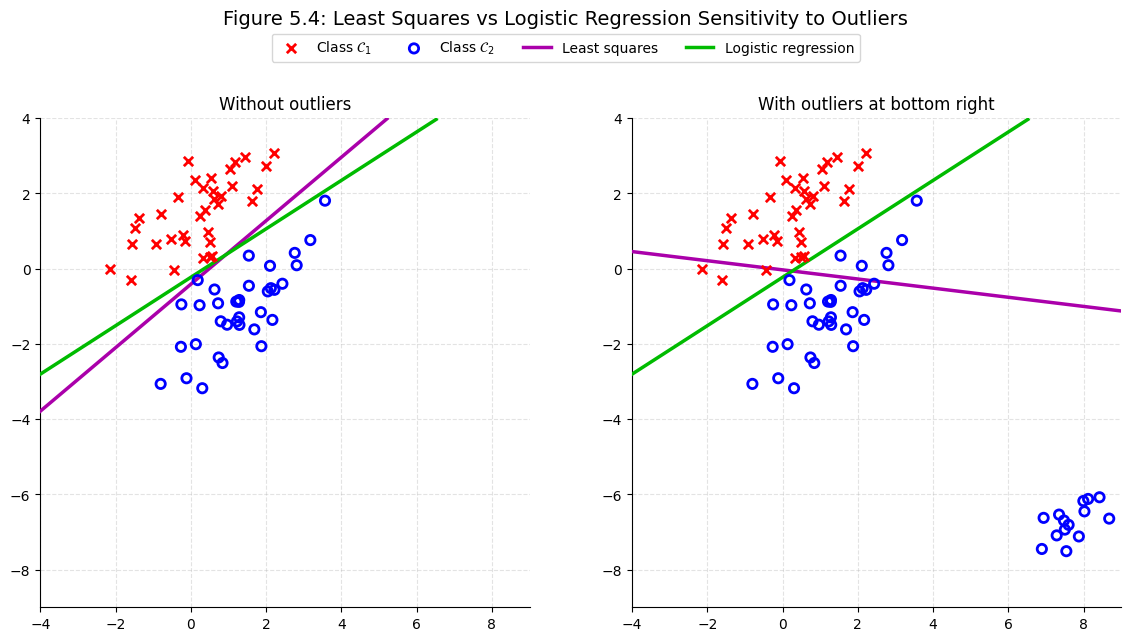

In [5]:
# 5.1.4 実装検証: 最小二乗分類器の総和制約 & 外れ値感度比較 (Figure 5.4)
# 1. 総和制約 sum_k y_k(x) = 1 (Eq 5.17 - 5.18) の数値検証
np.random.seed(10)
X_dummy = np.random.randn(50, 4)
labels_dummy = np.random.choice([0, 1, 2], size=50)
T_dummy = to_one_of_k(labels_dummy, num_classes=3)

ls_test = LeastSquaresClassifier().fit(X_dummy, T_dummy)
X_eval = np.random.uniform(-20, 20, size=(10, 4))  # 訓練データから極端に離れた任意点
Y_eval = ls_test.decision_function(X_eval)

print("--- 最小二乗法における線形制約保存 (Eq 5.18) の検証 ---")
print("任意評価点における出力ベクトル要素和:")
for i, y_vec in enumerate(Y_eval):
    print(f"  Point {i}: y = {np.round(y_vec, 3)}, sum = {np.sum(y_vec):.6f}")

assert ls_test.verify_sum_constraint(X_eval), "総和制約が満たされていません。"
print("全評価点で要素和が厳密に 1.0 であることが確認されました。")

# 2. Figure 5.4: 外れ値に対する感度の比較 (最小二乗法 vs ロジスティック回帰)
fig_5_4 = plot_figure_5_4_least_squares_outliers(filepath="result/fig_5_4_least_squares_outliers.png")
plt.show()

---
### 本節のまとめと次節への展望

本節（Section 5.1: Discriminant Functions）では、単層ネットワークによる分類の基礎となる線形識別関数を体系的に学習しました：

1. **2クラス線形識別関数 (Two classes)**:
   - $y(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + w_0 = 0$ は $(D-1)$ 次元の超平面決定境界を定義。
   - 法線ベクトル $\mathbf{w}$ は境界に直交し、向きを決定。原点からの距離は $-\frac{w_0}{\|\mathbf{w}\|}$。
   - 符号付き直交距離（マージン）は $r = \frac{y(\mathbf{x})}{\|\mathbf{w}\|}$ で与えられる。
2. **多クラス線形識別関数 (Multiple classes)**:
   - 1対他や1対1のヒューリスティックは曖昧・未分類領域を招く。
   - 統一的な $K$ クラス決定規則 $k^\star = \arg\max_k y_k(\mathbf{x})$ は曖昧性を完全に排除し、**決定領域は常に単連結かつ凸集合**となる。
3. **分類のための最小二乗法 (Least squares for classification)**:
   - 閉形式で解が求まり、1-of-K 符号化に対して要素和保存則 $\sum_k y_k(\mathbf{x}) = 1$ を満たす。
   - しかし、出力が $[0, 1]$ を逸脱し、**「正当側の遠方外れ値」に対して過大なペナルティを支払うことで決定境界が激しく歪む**という致命的弱点を持つ。

#### 次節 5.2 決定理論 (Decision Theory) への接続
本節で明らかになった通り、単に入力からクラスへの直接写像（識別関数）を作るだけでは、不確実性の定量化や外れ値への頑健性に限界があります。
次節 **Section 5.2: Decision Theory** では、誤分類率（Misclassification rate）の最小化、期待損失（Expected loss）の最小化、棄却オプション（The reject option）、推論と決定の分離（Inference and decision）、分類器の精度評価尺度、および ROC 曲線について詳解します。